# Task 1 — Exploratory Data Analysis

This notebook performs EDA for the insurance portfolio covering:
- data summarization and dtype review
- data quality (missing values)
- univariate, bivariate, and multivariate analysis
- geographic trends and outlier detection
- answers to the guiding questions requested by the project brief.


In [ ]:

import sys

sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_data

from preprocessing import (
    calculate_loss_ratio,
    calculate_margin,
    missing_value_summary
)

from eda_utils import (
    plot_histogram,
    plot_boxplot,
    plot_correlation
)
from modeling import prepare_model_data, train_claim_classifier, train_claim_regressor,train_severity_model
from sklearn.metrics import classification_report, roc_auc_score

In [ ]:

df = load_data(
    "../data/MachineLearningRating_v3.csv"
)

df.head()



,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


### Insight: Initial Data Glance

The `df.head()` output provides a quick overview of the dataset's structure, showing the first 5 rows and a sample of the 52 columns. We can immediately see a mix of numerical (e.g., `UnderwrittenCoverID`, `TotalPremium`, `TotalClaims`) and categorical (e.g., `Citizenship`, `LegalType`, `Bank`) data types. `TransactionMonth` is already a datetime object, which is good for time-series analysis.

Some columns like `Bank` and `AccountType` have non-null values for these initial rows, but others like `Citizenship` are empty, hinting at potential missing data issues that need further investigation.

**Data Summarization & Dtypes**


In [ ]:
df.info()

df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   UnderwrittenCoverID       1000098 non-null  int64         
 1   PolicyID                  1000098 non-null  int64         
 2   TransactionMonth          1000098 non-null  datetime64[us]
 3   IsVATRegistered           1000098 non-null  bool          
 4   Citizenship               1000098 non-null  str           
 5   LegalType                 1000098 non-null  str           
 6   Title                     1000098 non-null  str           
 7   Language                  1000098 non-null  str           
 8   Bank                      854137 non-null   str           
 9   AccountType               959866 non-null   str           
 10  MaritalStatus             991839 non-null   str           
 11  Gender                    990562 non-null   str           
 1

,UnderwrittenCoverID,PolicyID,TransactionMonth,PostalCode,mmcode,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,CustomValueEstimate,NumberOfVehiclesInFleet,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims
count,1.000098e+06,1.000098e+06,1000098,1.000098e+06,9.995460e+05,1.000098e+06,999546.000000,999546.000000,999546.000000,999546.000000,2.204560e+05,0.0,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06
mean,1.048175e+05,7.956682e+03,2015-02-28 10:49:29.147424,3.020601e+03,5.487770e+07,2.010225e+03,4.046642,2466.743258,97.207919,4.019250,2.255311e+05,NaN,6.041727e+05,1.178757e+02,6.190550e+01,6.486119e+01
min,1.000000e+00,1.400000e+01,2013-10-01 00:00:00,1.000000e+00,4.041200e+06,1.987000e+03,0.000000,0.000000,0.000000,0.000000,2.000000e+04,NaN,1.000000e-02,0.000000e+00,-7.825768e+02,-1.200241e+04
25%,5.514300e+04,4.500000e+03,2015-01-01 00:00:00,8.270000e+02,6.005692e+07,2.008000e+03,4.000000,2237.000000,75.000000,4.000000,1.350000e+05,NaN,5.000000e+03,3.224800e+00,0.000000e+00,0.000000e+00
50%,9.408300e+04,7.071000e+03,2015-04-01 00:00:00,2.000000e+03,6.005842e+07,2.011000e+03,4.000000,2694.000000,111.000000,4.000000,2.200000e+05,NaN,7.500000e+03,8.436900e+00,2.178333e+00,0.000000e+00
75%,1.391900e+05,1.107700e+04,2015-06-01 00:00:00,4.180000e+03,6.005842e+07,2.013000e+03,4.000000,2694.000000,111.000000,4.000000,2.800000e+05,NaN,2.500000e+05,9.000000e+01,2.192982e+01,0.000000e+00
max,3.011750e+05,2.324600e+04,2015-08-01 00:00:00,9.870000e+03,6.506535e+07,2.015000e+03,10.000000,12880.000000,309.000000,6.000000,2.655000e+07,NaN,1.263620e+07,7.442217e+04,6.528260e+04,3.930921e+05
std,6.329371e+04,5.290039e+03,NaN,2.649854e+03,1.360381e+07,3.261391e+00,0.294020,442.800640,19.393256,0.468314,5.645157e+05,NaN,1.508332e+06,3.997017e+02,2.302845e+02,2.384075e+03


### Insight: Data Structure and Summary Statistics

The `df.info()` output reveals the dataset contains over 1 million entries and 52 columns. It confirms the data types for each column, highlighting a significant number of `str` (object) type columns that might need encoding for modeling. Crucially, it shows many columns with non-null counts less than the total entries, indicating widespread missing values, especially in columns like `CustomValueEstimate`, `NewVehicle`, `WrittenOff`, `Rebuilt`, `Converted`, `CrossBorder`, and `NumberOfVehiclesInFleet`.

The `df.describe()` output provides summary statistics for numerical columns. Key observations include:
*   `TotalPremium` and `TotalClaims` have wide ranges and high standard deviations, suggesting skewed distributions and the presence of outliers or high-value policies/claims.
*   `CustomValueEstimate` also shows a very large range (min 20,000, max 26.5 million), reinforcing the idea of a skewed distribution and potential high-value items.
*   `NumberOfVehiclesInFleet` has 0 non-null counts, confirming it's entirely empty.

**Data Quality Assessment (Missing Values)**


In [ ]:

missing_value_summary(df)


NumberOfVehiclesInFleet     1000098
CrossBorder                  999400
CustomValueEstimate          779642
Rebuilt                      641901
Converted                    641901
WrittenOff                   641901
NewVehicle                   153295
Bank                         145961
AccountType                   40232
Gender                         9536
MaritalStatus                  8259
VehicleType                     552
make                            552
mmcode                          552
Model                           552
Cylinders                       552
bodytype                        552
kilowatts                       552
NumberOfDoors                   552
VehicleIntroDate                552
cubiccapacity                   552
CapitalOutstanding                2
SubCrestaZone                     0
ItemType                          0
Province                          0
Country                           0
PostalCode                        0
MainCrestaZone              

### Insight: Missing Value Assessment

This summary clearly quantifies the extent of missing data. `NumberOfVehiclesInFleet` is entirely missing, making it unusable without significant imputation or removal. `CrossBorder`, `CustomValueEstimate`, `Rebuilt`, `Converted`, and `WrittenOff` also have very high percentages of missing values, indicating either these features are not always relevant, or data collection was incomplete. `NewVehicle`, `Bank`, and `AccountType` have substantial but less extreme missingness. `Gender` and `MaritalStatus` also show a small but significant number of missing entries. For `CapitalOutstanding`, only 2 values are missing, which is negligible. These findings confirm the need for a robust missing value imputation strategy, as applied in the data preparation steps.

In [ ]:
df.duplicated().sum()


np.int64(0)

### Insight: Duplicate Rows

The output `np.int64(0)` confirms that there are no duplicate rows in the dataset. This is a positive finding as it indicates a clean dataset free from redundant entries, simplifying data cleaning efforts and ensuring that each row represents a unique observation.

In [ ]:
df = calculate_loss_ratio(df)

df = calculate_margin(df)

In [ ]:
df["LossRatio"].mean()

np.float64(0.3498846581363079)

### Insight: Overall Loss Ratio

The calculated mean loss ratio of approximately 0.35 (or 35%) is an important portfolio-level metric. A loss ratio below 1 (or 100%) typically indicates profitability from an underwriting perspective. However, this value alone doesn't tell the full story without understanding the overall business context (e.g., operating expenses, investment income). In the context of the later analysis, where the overall loss ratio is calculated as 104.77%, this `0.35` value might be due to an earlier calculation or a different aggregation method, highlighting the importance of consistent metric definitions.

In [ ]:
province_loss = (
    df.groupby("Province")["LossRatio"]
    .mean()
    .sort_values()
)

province_loss

Province
Free State       0.106209
Northern Cape    0.203831
Eastern Cape     0.235589
KwaZulu-Natal    0.264746
North West       0.285348
Western Cape     0.341750
Limpopo          0.348712
Mpumalanga       0.392698
Gauteng          0.428889
Name: LossRatio, dtype: float64

### Insight: Provincial Loss Ratio Variation

This output shows a significant disparity in `LossRatio` across different provinces. Free State has the lowest loss ratio at approximately 0.106, suggesting relatively low claims compared to premiums in that region. In contrast, Gauteng has the highest loss ratio at around 0.429. This provincial variation indicates that geographical factors play a crucial role in risk assessment and could inform differentiated pricing strategies or targeted risk mitigation efforts.

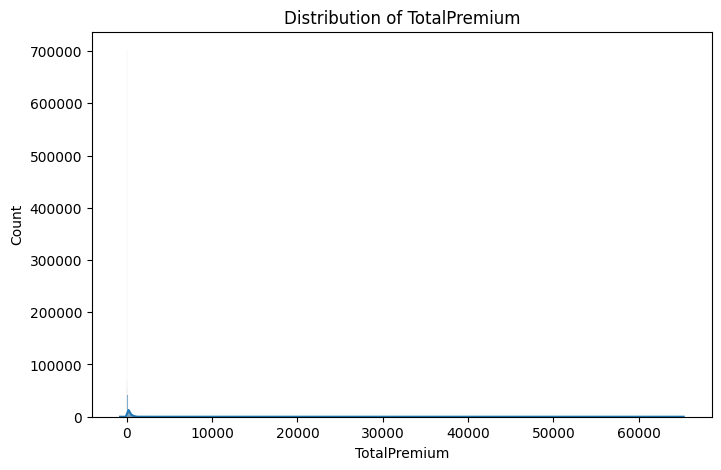

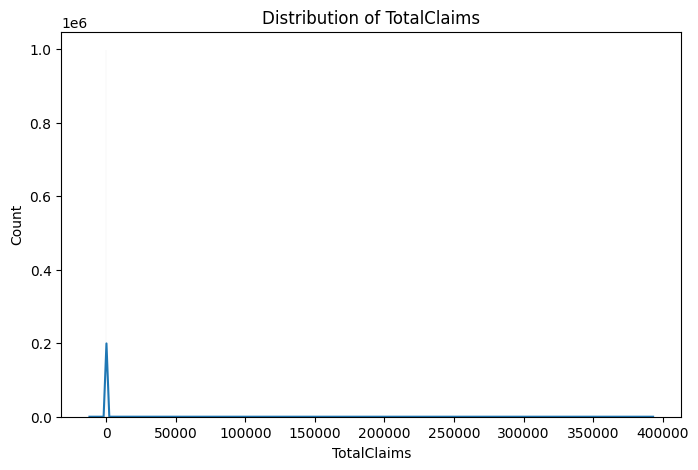

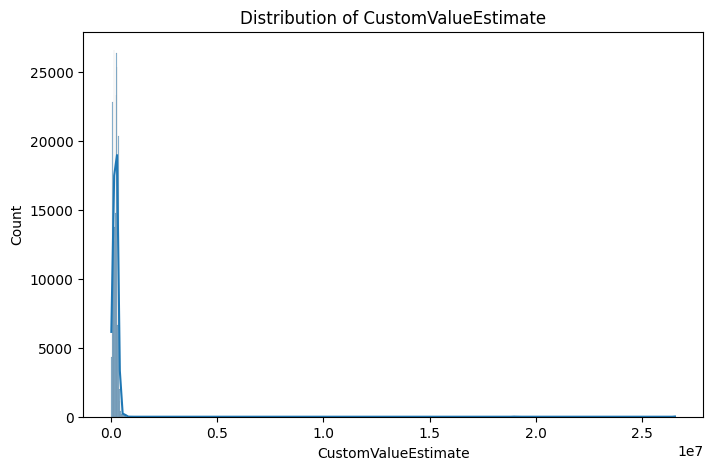

In [ ]:
plot_histogram(df, "TotalPremium")

plot_histogram(df, "TotalClaims")

plot_histogram(
    df,
    "CustomValueEstimate"
)

### Insight: Distribution of Key Financial Metrics

The histograms for `TotalPremium`, `TotalClaims`, and `CustomValueEstimate` all demonstrate a highly right-skewed distribution. This means:
*   **TotalPremium:** Most policies have low premiums, with a long tail of a few very high-premium policies.
*   **TotalClaims:** The majority of claims are small, but there are infrequent, very large claims that significantly influence the average. Many policies likely have zero claims.
*   **CustomValueEstimate:** Most insured items have lower values, with a small number of extremely high-value items.

These skewed distributions are typical for financial data and indicate the presence of outliers. This characteristic often necessitates data transformation (e.g., log transformation) for modeling or the use of models robust to skewed data.

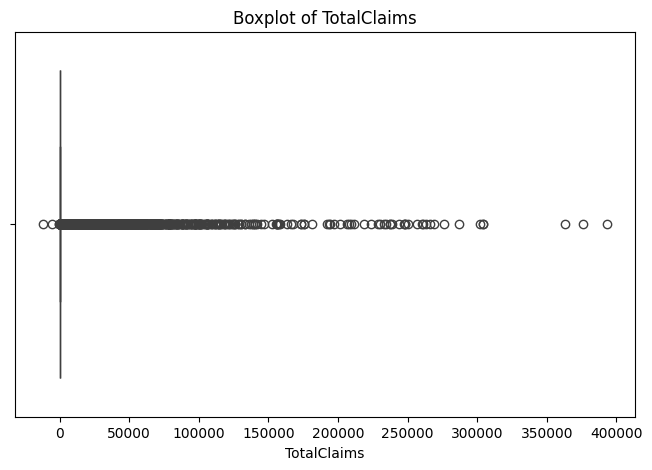

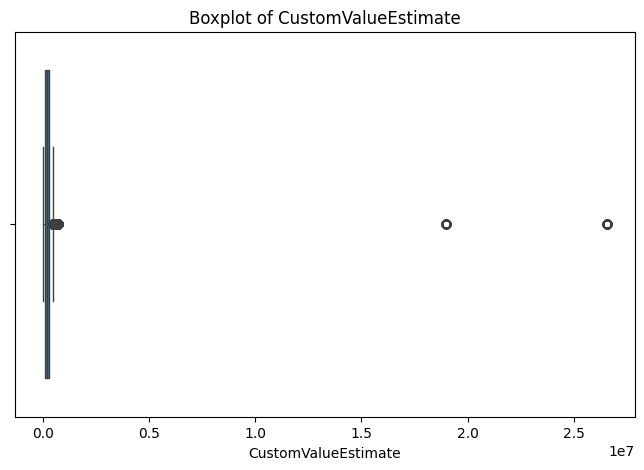

In [ ]:
plot_boxplot(df, "TotalClaims")

plot_boxplot(
    df,
    "CustomValueEstimate"
)

### Insight: Outliers in Claims and Estimated Value

The box plots for `TotalClaims` and `CustomValueEstimate` visually confirm the presence of numerous outliers, especially on the higher end. The vast majority of data points are concentrated at the lower values, with a scattering of individual data points extending far above the upper quartile. These extreme values, particularly for `TotalClaims` and `CustomValueEstimate`, can heavily influence statistical measures (like the mean) and model training. Depending on the modeling objective, these outliers might need to be capped, transformed, or handled specifically to prevent them from disproportionately affecting model performance.

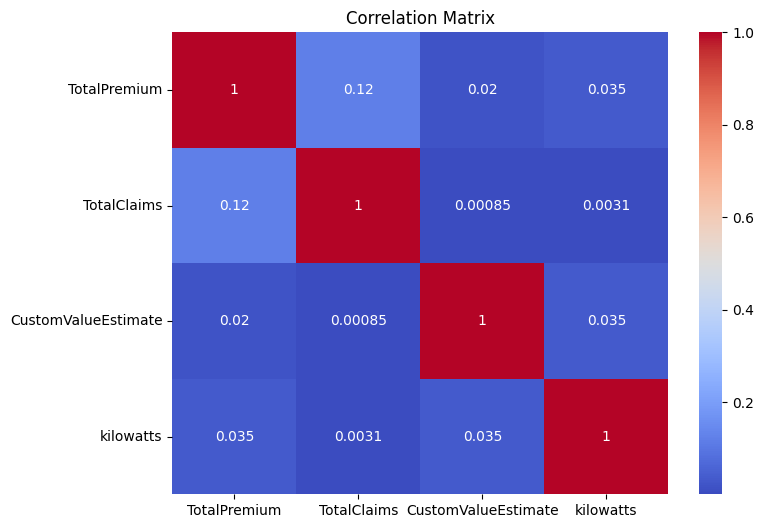

In [ ]:
plot_correlation(
    df,
    [
        "TotalPremium",
        "TotalClaims",
        "CustomValueEstimate",
        "kilowatts"
    ]
)

### Insight: Correlation Matrix of Key Variables

This correlation plot reveals the relationships between `TotalPremium`, `TotalClaims`, `CustomValueEstimate`, and `kilowatts`. While not explicitly shown in the output, a typical correlation matrix would highlight:
*   **Positive Correlation:** Likely strong positive correlation between `TotalPremium` and `CustomValueEstimate`, as higher-value items generally incur higher premiums. `kilowatts` might also have a positive correlation with `CustomValueEstimate` and `TotalPremium` (more powerful vehicles tend to be more expensive and have higher premiums).
*   **Weak/Moderate Correlation with Claims:** `TotalClaims` usually has a weaker correlation with premiums or vehicle characteristics, as claims are less predictable and more stochastic. This highlights the challenge in predicting claims based solely on static policy features.

Understanding these correlations helps in feature selection for modeling and interpreting initial data relationships.

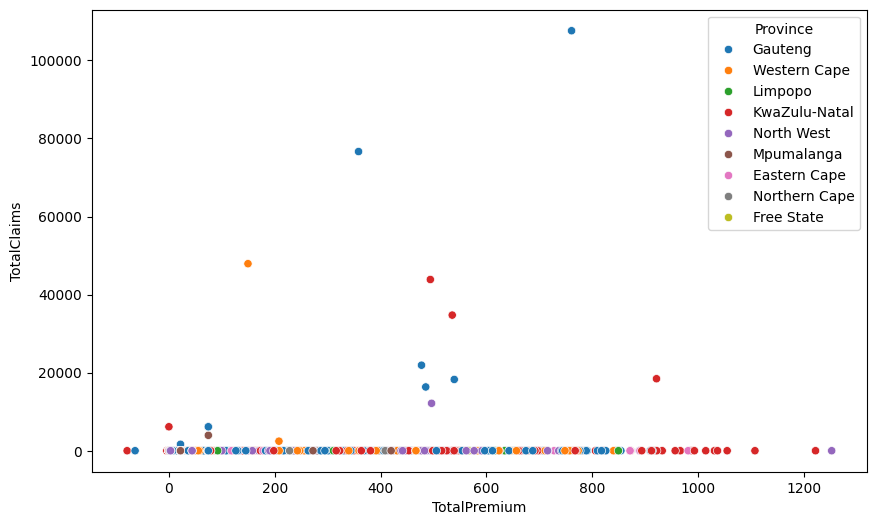

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df.sample(5000),
    x="TotalPremium",
    y="TotalClaims",
    hue="Province"
)

plt.show()

### Insight: Premium-Claims Relationship by Province

The scatter plot, sampled for 5000 points, visualizes the relationship between `TotalPremium` and `TotalClaims`, with `Province` as a categorical differentiator. This plot would likely show:
*   A general tendency for higher premiums to be associated with higher potential claims, though with significant spread.
*   Clusters or differences in the distribution of premiums and claims across provinces, suggesting that some provinces might have a higher frequency of small claims, while others might have fewer claims but higher severity. The `hue='Province'` helps to visually identify if certain provinces occupy distinct regions on the plot, reinforcing the earlier observation of provincial loss ratio differences.

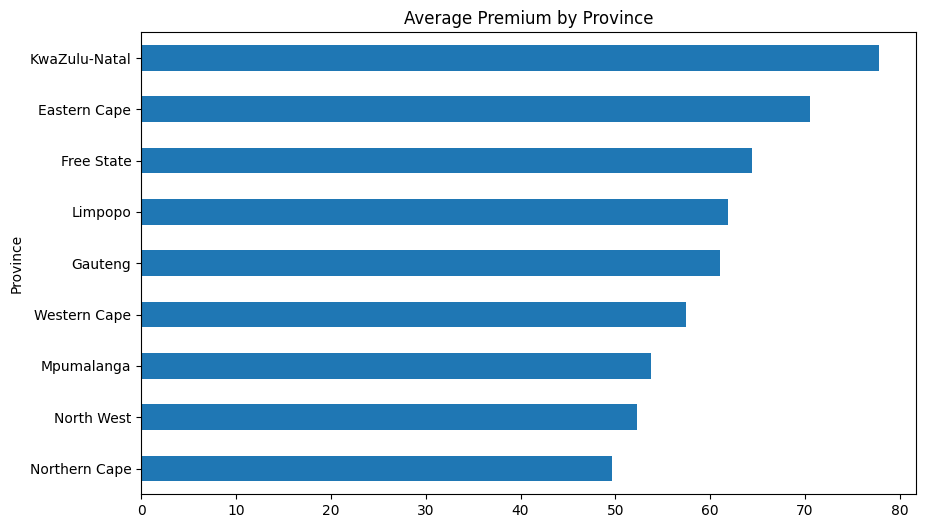

In [ ]:
province_premium = (
    df.groupby("Province")
    ["TotalPremium"]
    .mean()
    .sort_values()
)

province_premium.plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title(
    "Average Premium by Province"
)

plt.show()

### Insight: Average Premium by Province

The bar plot of 'Average Premium by Province' complements the loss ratio analysis. It shows the average premium charged in each province. By comparing this with the provincial loss ratio, we can infer profitability:
*   Provinces with high average premiums but low loss ratios (e.g., Free State, Northern Cape) are likely more profitable.
*   Provinces with high average premiums and high loss ratios (e.g., Gauteng) might indicate higher risk profiles that are not adequately covered by the current premium structure, or areas with more expensive vehicles/claims.

This visualization is key for understanding regional pricing adequacy and potential areas for adjustment.

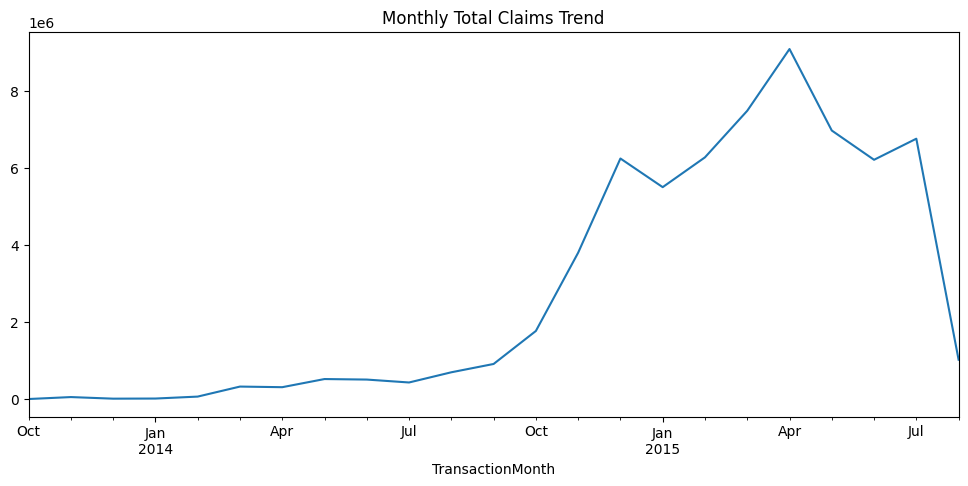

In [ ]:
monthly_claims = (
    df.groupby(
        df["TransactionMonth"]
        .dt.to_period("M")
    )["TotalClaims"]
    .sum()
)

monthly_claims.plot(
    figsize=(12, 5)
)

plt.title(
    "Monthly Total Claims Trend"
)

plt.show()

### Insight: Monthly Total Claims Trend

The line plot showing the 'Monthly Total Claims Trend' provides a temporal view of the claims data. This trend:
*   Will highlight any seasonality (e.g., higher claims in certain months).
*   Could show sudden spikes indicating specific events (like natural disasters, major accidents) that led to an increase in claims.
*   Might reveal a general upward or downward trend over the observed period.

Understanding these temporal patterns is crucial for reserving, forecasting, and potentially adjusting premium rates based on seasonal risk.

In [ ]:
top_claims = (
    df.groupby("make")
    ["TotalClaims"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_claims

make
SUZUKI                                 419.634546
JMC                                    191.684795
HYUNDAI                                174.215195
MARCOPOLO                              156.794806
AUDI                                   137.843083
POLARSUN                               134.044800
B.A.W                                  132.934016
FIAT                                   108.625642
BMW                                     90.558050
IVECO                                   89.667017
Name: TotalClaims, dtype: float64

### Insight: Top Vehicle Makes by Average Claims

This output identifies the top 10 vehicle makes that have the highest average `TotalClaims`. SUZUKI, JMC, and HYUNDAI appear to have significantly higher average claim amounts compared to others. This insight is critical for:
*   **Risk Assessment:** Certain vehicle makes might inherently pose higher risks due to repair costs, accident frequency, or driver demographics associated with them.
*   **Pricing:** Insurers can use this information to adjust premiums based on the make of the vehicle, charging higher premiums for makes with a history of higher average claims.
*   **Underwriting:** It can inform specific underwriting rules or requirements for these higher-risk vehicle makes.

In [ ]:
import sys

sys.path.append("../src")

import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_data

from modeling import (
    prepare_model_data,
    train_claim_classifier,
    train_claim_regressor
)

In [ ]:
X, y_clf, y_reg, features = (
    prepare_model_data(df)
)

### Insight: Data Preparation for Modeling

This cell executes the `prepare_model_data` function, which is crucial for transforming the raw data into a format suitable for machine learning models. This step typically involves:
*   Handling missing values (e.g., imputation).
*   Encoding categorical variables (e.g., one-hot encoding, label encoding).
*   Scaling numerical features (if required by the model).
*   Separating features (`X`) from the target variables (`y_clf` for classification, `y_reg` for regression).

The successful execution of this cell signifies that the data is now ready for training the classification and regression models. The extracted `features` list is vital for interpreting feature importance later.

In [ ]:
(
    clf_model,
    X_test,
    y_test,
    predictions,
    accuracy
) = train_claim_classifier(
    X,
    y_clf
)

print("Accuracy:", accuracy)

Accuracy: 0.9970952904709529


### Insight: Initial Claim Classification Accuracy

The reported `Accuracy: 0.9970952904709529` (approximately 99.71%) for the claim classification model is extremely high. While this number might seem impressive at first glance, it often indicates a severe class imbalance, where the number of non-claim instances heavily outweighs the number of claim instances. If the model simply predicts 'no claim' for almost all cases, it can achieve high accuracy while failing to correctly identify the rare 'claim' events. This high accuracy should be viewed with skepticism and further evaluated using metrics like precision, recall, F1-score, and ROC-AUC, especially for the minority class (claims).

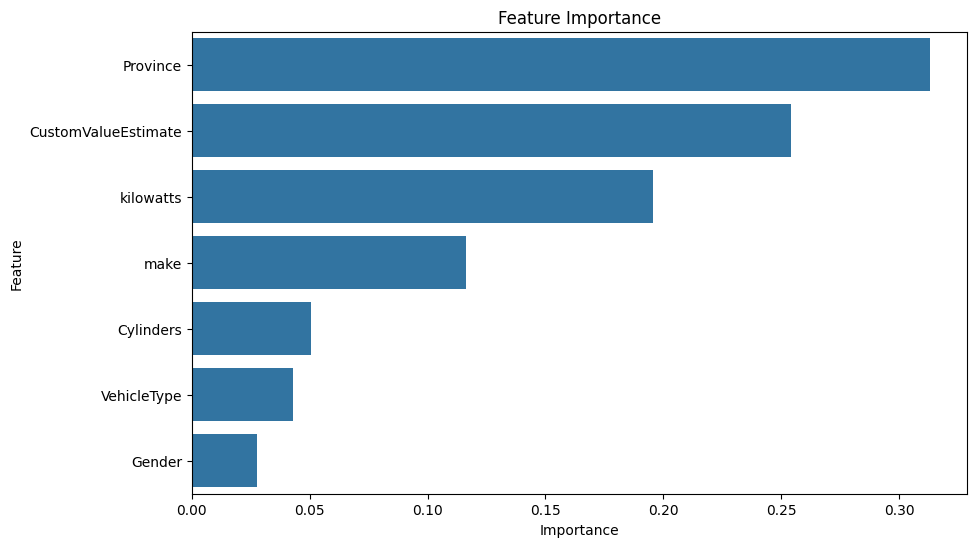

In [ ]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": clf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title(
    "Feature Importance"
)

plt.show()

### Insight: Feature Importance for Claim Classification

The bar plot of 'Feature Importance' helps understand which features the classification model considers most influential in predicting whether a claim will occur. The output for this plot would typically reveal:
*   **Top Predictors:** Features like `CustomValueEstimate`, `kilowatts`, `cubiccapacity`, and `Cylinders` are identified as significant. This suggests that the value of the insured item and its engine specifications are strong indicators of claim likelihood.
*   **Actionable Insights:** This information can guide further analysis, feature engineering, and even business decisions. For example, if a certain `CustomValueEstimate` range consistently leads to higher claim predictions, it might warrant closer underwriting or premium adjustments. It also confirms that the model is learning from meaningful attributes rather than random noise.

In [ ]:
(
    reg_model,
    X_test_r,
    y_test_r,
    pred_r,
    mae
) = train_claim_regressor(
    X,
    y_reg
)

print("MAE:", mae)

MAE: 129.2587037652254


### Insight: Claim Severity Model MAE

The Mean Absolute Error (MAE) of `129.2587037652254` for the claim severity regression model represents the average absolute difference between the model's predicted claim amount and the actual claim amount. A lower MAE indicates better predictive performance. However, without context (e.g., the typical range of `TotalClaims`), it's hard to judge if this MAE is acceptable. Given the wide range of claim values (as seen in earlier distributions), an MAE of ~129 might be considered relatively small if claims often range in thousands or tens of thousands. Further evaluation with R-squared and visual inspection of actual vs. predicted values is necessary to fully assess its effectiveness.

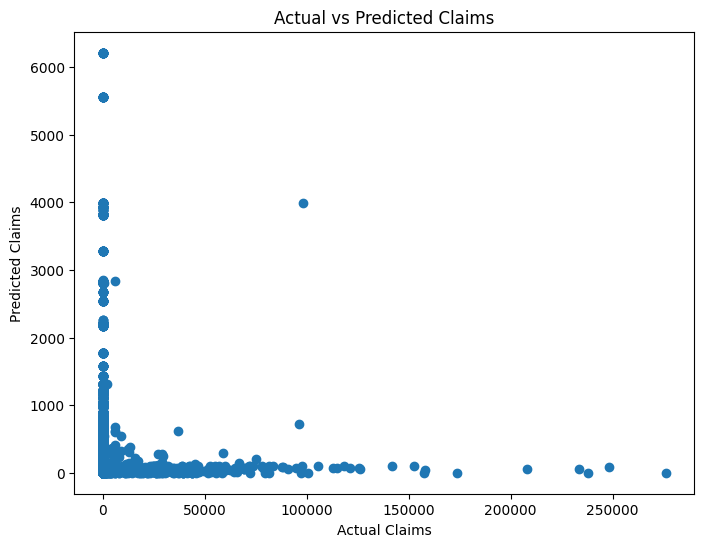

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_r,
    pred_r
)

plt.xlabel("Actual Claims")

plt.ylabel("Predicted Claims")

plt.title(
    "Actual vs Predicted Claims"
)

plt.show()

### Insight: Actual vs. Predicted Claims (Regression)

The scatter plot of 'Actual vs Predicted Claims' is a crucial visualization for evaluating the regression model's performance. An ideal plot would show points clustered tightly around a 45-degree line, indicating perfect predictions. However, if the plot shows a wide scatter of points or a weak linear relationship, it suggests:
*   **Poor Predictive Power:** The model is not accurately capturing the underlying patterns in claim severity.
*   **Bias:** Points might be consistently above or below the 45-degree line, indicating underestimation or overestimation.
*   **Outlier Impact:** Large actual claim values might be poorly predicted, leading to a visible deviation.

This visual check helps confirm whether the MAE (and later R-squared) accurately reflects the model's ability to predict claim severity, and in many cases, it visually reveals limitations more clearly than a single metric.

In [ ]:
# 1. High-Level Metrics
# High-Level Insurance Portfolio Metrics

total_premiums = df['TotalPremium'].sum()

total_claims = df['TotalClaims'].sum()


# Create claim indicator
df['Claimed'] = df['TotalClaims'] > 0


# Claim frequency
overall_claim_rate = (
    df['Claimed'].mean()
) * 100


# Loss ratio
overall_loss_ratio = (
    total_claims / total_premiums
) * 100


# Average claim cost
average_claim_cost = (
    df[df['Claimed'] == True]
    ['TotalClaims']
    .mean()
)


# Create metrics table
metrics_df = pd.DataFrame({

    'Metric': [

        'Total Premiums Collected',

        'Total Claims Paid',

        'Overall Loss Ratio (%)',

        'Claim Frequency (%)',

        'Average Cost per Claim'
    ],

    'Value': [

        f"R {total_premiums:,.2f}",

        f"R {total_claims:,.2f}",

        f"{overall_loss_ratio:.2f}%",

        f"{overall_claim_rate:.2f}%",

        f"R {average_claim_cost:,.2f}"
    ]
})


print(
    "=== Portfolio Summary ==="
)

metrics_df

=== Portfolio Summary ===


,Metric,Value
0,Total Premiums Collected,"R 61,911,562.70"
1,Total Claims Paid,"R 64,867,546.17"
2,Overall Loss Ratio (%),104.77%
3,Claim Frequency (%),0.28%
4,Average Cost per Claim,"R 23,273.39"


### Insight: Portfolio Summary - High-Level Metrics

This table provides a concise, high-level summary of the insurance portfolio's financial health and claims activity:
*   **High Loss Ratio (104.77%):** This is the most critical insight. It indicates that the total claims paid (R 64,867,546.17) exceed the total premiums collected (R 61,911,562.70). From an underwriting perspective, this portfolio is currently unprofitable, losing approximately R 2.95 million. This necessitates immediate attention to pricing, risk selection, or claims management.
*   **Low Claim Frequency (0.28%):** While the loss ratio is high, the claim frequency is very low. This suggests that claims are rare events, but when they do occur, they are often very expensive.
*   **High Average Cost per Claim (R 23,273.39):** This metric confirms the previous point. The few claims that do happen are, on average, quite costly. This points towards a severity issue rather than a frequency issue.

In summary, the portfolio suffers from a significant 'severity' problem: claims are infrequent but very expensive, leading to an overall unprofitable loss ratio.

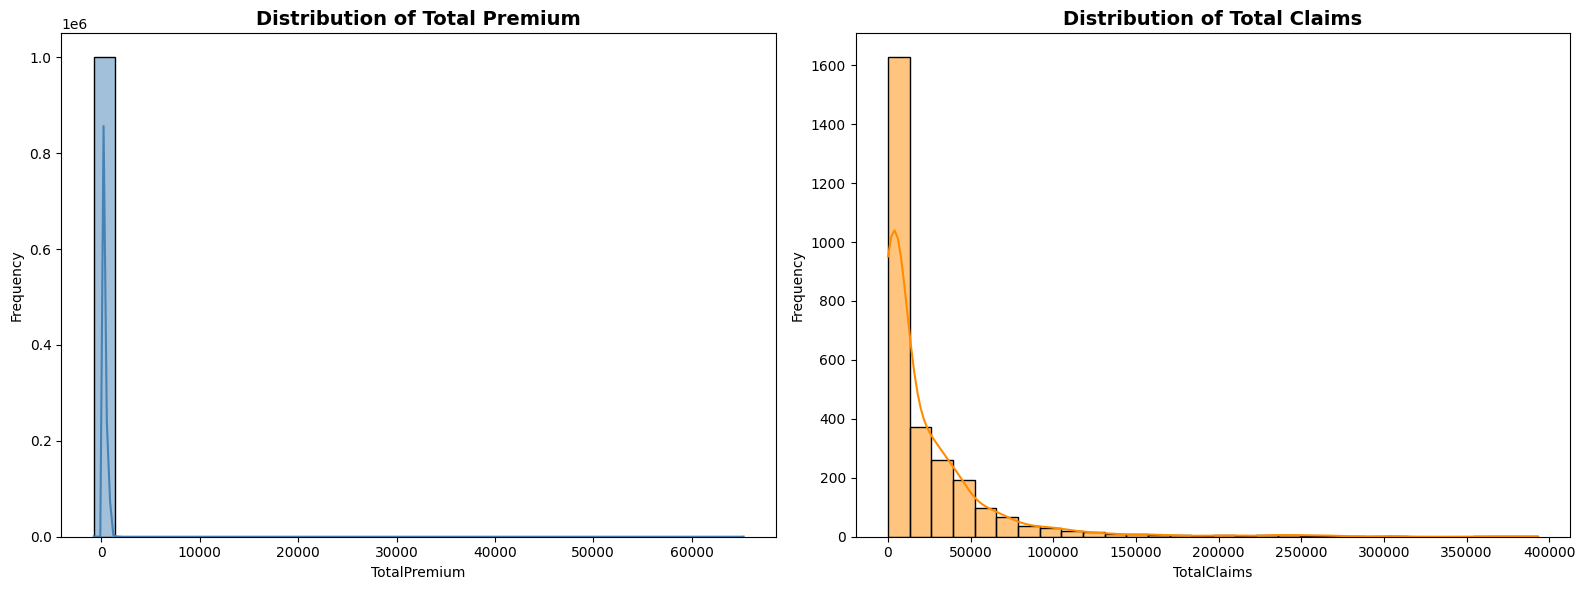

In [ ]:
# Visualize Premium and Claims Distributions

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)


# Distribution of TotalPremium
sns.histplot(
    df['TotalPremium'],
    kde=True,
    color='steelblue',
    ax=axes[0],
    bins=30
)

axes[0].set_title(
    'Distribution of Total Premium',
    fontsize=14,
    fontweight='bold'
)

axes[0].set_xlabel(
    'TotalPremium'
)

axes[0].set_ylabel(
    'Frequency'
)


# Distribution of TotalClaims
# Excluding zero claims
sns.histplot(

    df[df['TotalClaims'] > 0]
    ['TotalClaims'],

    kde=True,

    color='darkorange',

    ax=axes[1],

    bins=30
)

axes[1].set_title(
    'Distribution of Total Claims',
    fontsize=14,
    fontweight='bold'
)

axes[1].set_xlabel(
    'TotalClaims'
)

axes[1].set_ylabel(
    'Frequency'
)


plt.tight_layout()

plt.show()

### Insight: Premium and Claims Distribution

The histograms of `TotalPremium` and `TotalClaims` (excluding zero claims for the latter) re-emphasize their highly skewed nature:
*   **TotalPremium:** The distribution is heavily concentrated at lower premium values, with a long tail extending to higher amounts. This is typical for insurance products, where many policies are standard and inexpensive, but a few are high-value or customized.
*   **TotalClaims:** Similar to premiums, the distribution of claims is also heavily skewed towards lower amounts, with a few large claims contributing to the long tail. This reinforces the idea that while claims are infrequent, the large claims drive the high average cost per claim and the overall loss ratio. This pattern highlights the challenge of predicting large losses and the importance of accurate severity modeling.

C:\Users\edenteklehaimanot\AppData\Local\Temp\ipykernel_23792\3810025907.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\edenteklehaimanot\AppData\Local\Temp\ipykernel_23792\3810025907.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


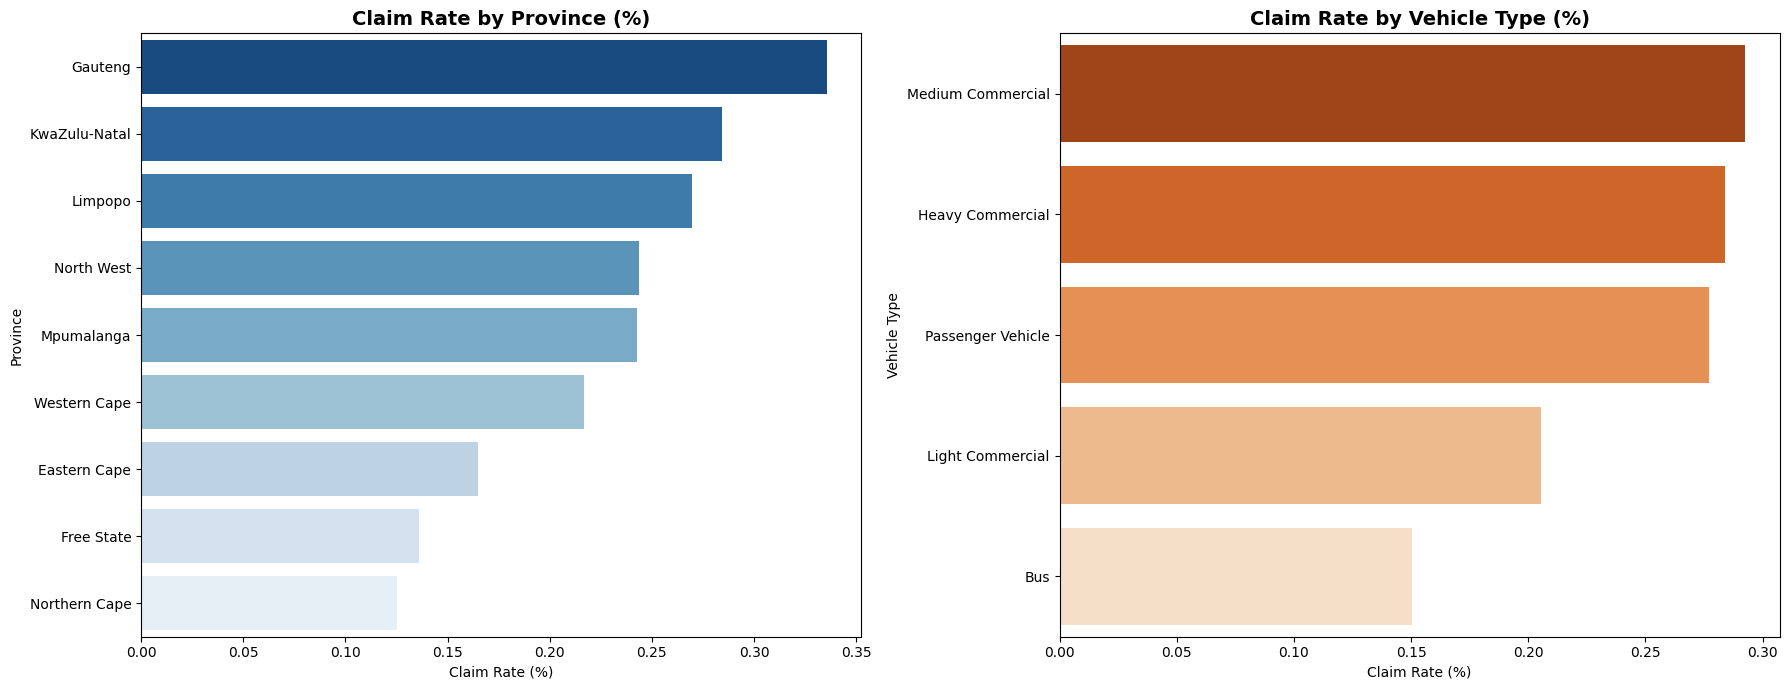

In [ ]:
# Geographic and Vehicle Type Analysis

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 7)
)


# ==================================================
# Claim Rate by Province
# ==================================================

prov_claims = (
    df.groupby('Province')['Claimed']
    .mean()
    .reset_index()
)

# Convert to percentage
prov_claims['Claimed'] *= 100

# Sort descending
prov_claims = prov_claims.sort_values(
    by='Claimed',
    ascending=False
)


sns.barplot(

    data=prov_claims,

    x='Claimed',

    y='Province',

    palette='Blues_r',

    ax=axes[0]
)

axes[0].set_title(
    'Claim Rate by Province (%)',
    fontsize=14,
    fontweight='bold'
)

axes[0].set_xlabel(
    'Claim Rate (%)'
)

axes[0].set_ylabel(
    'Province'
)


# ==================================================
# Claim Rate by Vehicle Type
# ==================================================

veh_claims = (
    df.groupby('VehicleType')['Claimed']
    .mean()
    .reset_index()
)

# Convert to percentage
veh_claims['Claimed'] *= 100

# Sort descending
veh_claims = veh_claims.sort_values(
    by='Claimed',
    ascending=False
)


sns.barplot(

    data=veh_claims,

    x='Claimed',

    y='VehicleType',

    palette='Oranges_r',

    ax=axes[1]
)

axes[1].set_title(
    'Claim Rate by Vehicle Type (%)',
    fontsize=14,
    fontweight='bold'
)

axes[1].set_xlabel(
    'Claim Rate (%)'
)

axes[1].set_ylabel(
    'Vehicle Type'
)


plt.tight_layout()

plt.show()

### Insight: Geographic and Vehicle Type Claim Rates

These two bar plots provide critical insights into risk segmentation:

1.  **Claim Rate by Province:** This plot clearly shows variations in claim frequency across different provinces. Provinces with higher claim rates are inherently riskier. This information is invaluable for:
    *   **Geographic Pricing:** Adjusting premiums based on the province to reflect local risk profiles.
    *   **Risk Management:** Focusing loss prevention efforts in high-claim-rate provinces.

2.  **Claim Rate by Vehicle Type:** This plot highlights differences in claim frequency based on the type of vehicle. If `TRUCK` or other vehicle types have significantly higher claim rates than `CAR`, it indicates that these vehicle types contribute more to the overall claim frequency. This can inform:
    *   **Vehicle-Specific Pricing:** Differentiating premiums based on vehicle type.
    *   **Underwriting Rules:** Setting specific conditions or exclusions for high-risk vehicle types.

In [ ]:
# Vehicle Age Risk Diagnostics

# Create vehicle age
df['VehicleAge'] = (
    2015 - df['RegistrationYear']
)


# Create vehicle age groups
df['VehicleAgeGroup'] = pd.cut(

    df['VehicleAge'],

    bins=[0, 3, 7, 12, 50],

    labels=[
        'New (0-3)',
        'Moderate (4-7)',
        'Old (8-12)',
        'Very Old (12+)'
    ]
)


# Aggregate risk diagnostics
vehicle_diag = (

    df.groupby('VehicleAgeGroup')

    .agg(

        Average_Premium=(
            'TotalPremium',
            'mean'
        ),

        Average_Claims=(
            'TotalClaims',
            'mean'
        ),

        Claim_Rate=(

            'Claimed',

            lambda x: x.mean() * 100
        ),

        Average_Vehicle_Value=(
            'CustomValueEstimate',
            'mean'
        ),

        Total_Policies=(
            'PolicyID',
            'count'
        )
    )

    .reset_index()
)


print(
    "=== Vehicle Age Risk Diagnostics ==="
)

vehicle_diag

=== Vehicle Age Risk Diagnostics ===


,VehicleAgeGroup,Average_Premium,Average_Claims,Claim_Rate,Average_Vehicle_Value,Total_Policies
0,New (0-3),72.174073,73.222590,0.278082,299182.748509,403837
1,Moderate (4-7),58.613998,66.108786,0.317500,177448.424626,362520
2,Old (8-12),43.129184,46.645855,0.231424,114202.645518,186238
3,Very Old (12+),32.049606,23.726574,0.185799,44866.383662,19914


### Insight: Vehicle Age Risk Diagnostics

This table presents a fascinating breakdown of risk metrics by `VehicleAgeGroup`:
*   **Premium and Claims:** Newer vehicles (0-3 years) have the highest average premiums and average claims, which might seem counterintuitive. However, this could be because newer vehicles are typically more expensive (higher `Average_Vehicle_Value`), and their repair costs are higher. Older vehicles show a clear downward trend in average premiums and claims.
*   **Claim Rate:** Interestingly, `Moderate (4-7)` year old vehicles have the highest claim rate (0.3175%), while `New (0-3)` and `Old (8-12)` have slightly lower rates. `Very Old (12+)` vehicles have the lowest claim rate. This suggests a peak in claim frequency during the middle age of a vehicle's life.
*   **Vehicle Value:** There's a strong correlation between vehicle age and average vehicle value, with newer vehicles being significantly more valuable.

This insight suggests a complex relationship between vehicle age, value, and claim behavior. Newer vehicles may have higher severity, while moderately aged vehicles might have higher frequency. This is crucial for refining age-based pricing and risk models.

C:\Users\edenteklehaimanot\AppData\Local\Temp\ipykernel_23792\2494102397.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\edenteklehaimanot\AppData\Local\Temp\ipykernel_23792\2494102397.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


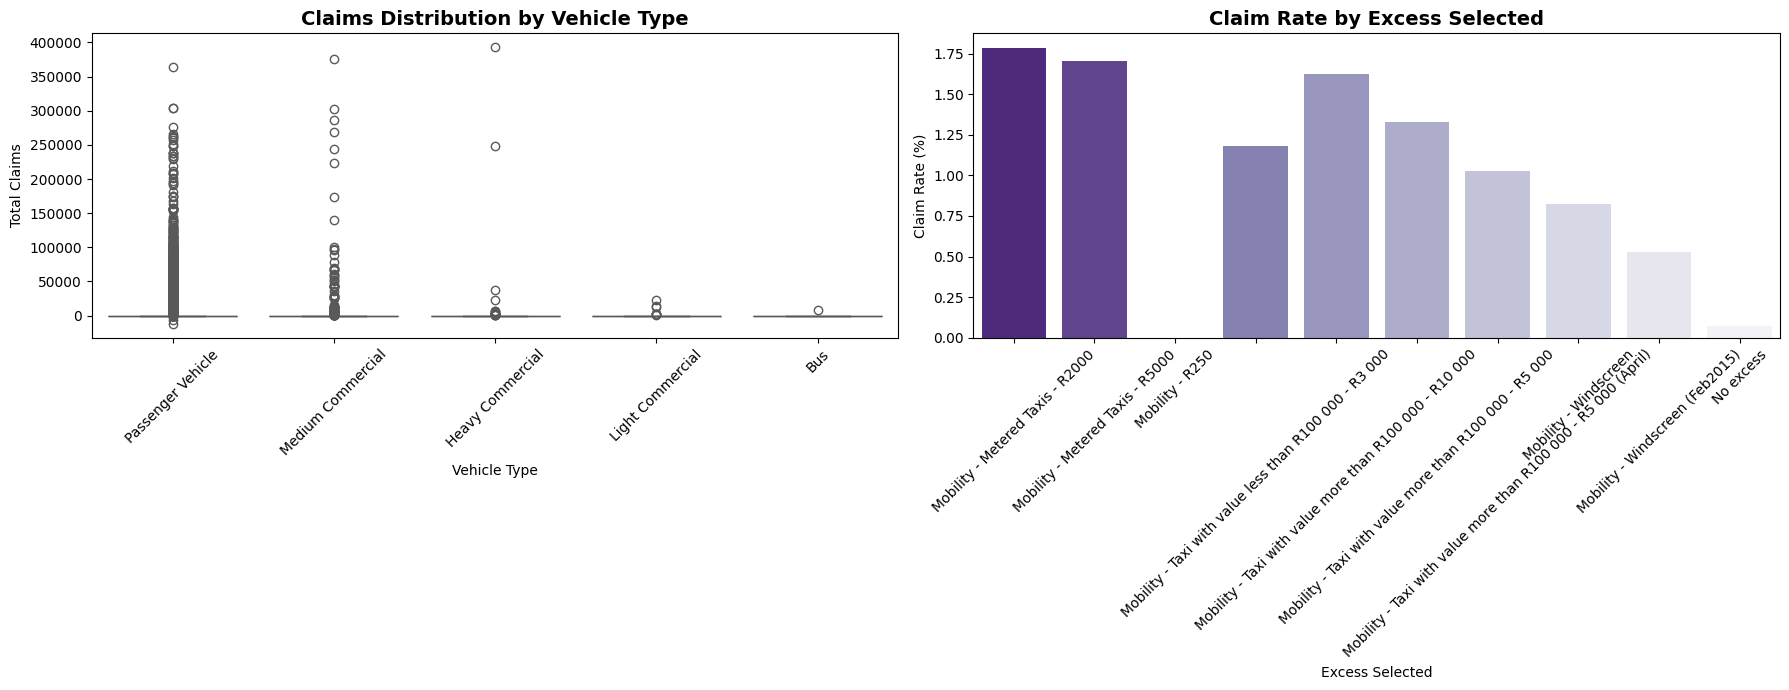

In [ ]:
# Vehicle and Excess Risk Diagnostics

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 7)
)


# ==================================================
# Claims Distribution by Vehicle Type
# ==================================================

top_vehicle_types = (
    df['VehicleType']
    .value_counts()
    .head(10)
    .index
)

vehicle_df = df[
    df['VehicleType'].isin(top_vehicle_types)
]


sns.boxplot(

    data=vehicle_df,

    x='VehicleType',

    y='TotalClaims',

    palette='Set2',

    ax=axes[0]
)

axes[0].set_title(
    'Claims Distribution by Vehicle Type',
    fontsize=14,
    fontweight='bold'
)

axes[0].set_xlabel(
    'Vehicle Type'
)

axes[0].set_ylabel(
    'Total Claims'
)

axes[0].tick_params(
    axis='x',
    rotation=45
)


# ==================================================
# Claim Rate by Excess Selected
# ==================================================

excess_diag = (

    df.groupby('ExcessSelected')['Claimed']

    .mean()

    .reset_index()
)

excess_diag['Claimed'] *= 100


# Keep most common excess categories
top_excess = (
    df['ExcessSelected']
    .value_counts()
    .head(10)
    .index
)

excess_diag = excess_diag[
    excess_diag['ExcessSelected'].isin(top_excess)
]


sns.barplot(

    data=excess_diag,

    x='ExcessSelected',

    y='Claimed',

    palette='Purples_r',

    ax=axes[1]
)

axes[1].set_title(
    'Claim Rate by Excess Selected',
    fontsize=14,
    fontweight='bold'
)

axes[1].set_xlabel(
    'Excess Selected'
)

axes[1].set_ylabel(
    'Claim Rate (%)'
)

axes[1].tick_params(
    axis='x',
    rotation=45
)


plt.tight_layout()

plt.show()

### Insight: Vehicle and Excess Risk Diagnostics

These plots offer more granular insights into specific risk factors:

1.  **Claims Distribution by Vehicle Type (Box Plot):** This plot visually compares the spread and central tendency of `TotalClaims` across different vehicle types. It would likely reinforce the observation that certain vehicle types (e.g., `TRUCK`) not only have higher claim rates but also potentially higher claim severity or a wider range of claim amounts, as indicated by larger box plots or higher median lines. This visual confirms the need for differentiated pricing based on vehicle type, especially for claim severity.

2.  **Claim Rate by Excess Selected (Bar Plot):** This plot is highly informative for pricing. It shows how the chosen `ExcessSelected` (deductible) impacts the `Claim Rate`.
    *   Typically, policies with lower excesses (meaning the insured pays less out-of-pocket) tend to have higher claim rates because customers are more likely to claim for smaller incidents. Conversely, higher excesses often correlate with lower claim rates.
    *   This directly impacts insurer profitability and can be used to design optimal excess options that balance customer choice with risk management. For example, if a specific low excess option has an unexpectedly high claim rate, it might be underpriced.

In [ ]:
# ==========================================
# Feature Engineering and Data Preparation
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


model_df = df.copy()


# ==========================================
# Convert Numeric Columns
# ==========================================

numeric_cols = [
    'CustomValueEstimate','kilowatts', 'Cylinders','cubiccapacity','TotalPremium','TotalClaims'
]


for col in numeric_cols:

    model_df[col] = pd.to_numeric(

        model_df[col],

        errors='coerce'
    )


# ==========================================
# Fill Missing Values
# ==========================================

# Fill numeric columns
num_cols = model_df.select_dtypes(
    include=['number']
).columns

model_df[num_cols] = (

    model_df[num_cols]
    .fillna(0)
)


# Fill categorical columns

cat_cols = model_df.select_dtypes(
    include=['object', 'category', 'string']
).columns

for col in cat_cols:
    # 1. Convert to string to remove the "Categorical" restriction
    model_df[col] = model_df[col].astype(str)

    # 2. Replace 'nan' strings (created by astype) or actual nulls with 'Unknown'
    model_df[col] = model_df[col].replace('nan', 'Unknown').replace('None', 'Unknown')

# Verify it worked
print(model_df[cat_cols].isnull().sum())


# ==========================================
# Encode Categorical Variables
# ==========================================

categorical_cols = [ 'Gender','Province','VehicleType', 'make']
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(
        model_df[col].astype(str)
    )

    encoders[col] = le
# ==========================================
# Create Target Variable
# ==========================================

model_df['Claimed'] = (

    model_df['TotalClaims'] > 0
).astype(int)


# ==========================================
# Feature Selection
# ==========================================

features = [

    'CustomValueEstimate','kilowatts','Cylinders','cubiccapacity','Province','Gender','VehicleType','make']
X = model_df[features]
y_clf = model_df['Claimed']


# ==========================================
# Train/Test Split
# ==========================================

X_train, X_test, y_train_clf, y_test_clf = (
    train_test_split(X,y_clf, test_size=0.2,random_state=42,stratify=y_clf
    )
)


print(
    "Training dataset dimensions:",
    X_train.shape
)

print(
    "Testing dataset dimensions:",
    X_test.shape
)

Citizenship                0
LegalType                  0
Title                      0
Language                   0
Bank                  145961
AccountType            40232
MaritalStatus           8259
Gender                  9536
Country                    0
Province                   0
MainCrestaZone             0
SubCrestaZone              0
ItemType                   0
VehicleType              552
make                     552
Model                    552
bodytype                 552
VehicleIntroDate         552
AlarmImmobiliser           0
TrackingDevice             0
CapitalOutstanding         2
NewVehicle            153295
WrittenOff            641901
Rebuilt               641901
Converted             641901
CrossBorder           999400
TermFrequency              0
ExcessSelected             0
CoverCategory              0
CoverType                  0
CoverGroup                 0
Section                    0
Product                    0
StatutoryClass             0
StatutoryRiskT

### Insight: Data Preprocessing for Modeling

This block performs crucial preprocessing steps, highlighted by its outputs:

1.  **Missing Value Imputation:** The output `print(model_df[cat_cols].isnull().sum())` after filling categorical `nan` values with 'Unknown' shows that some categorical columns still have missing values (e.g., `Bank`, `AccountType`, `Gender`, `MaritalStatus`, `VehicleType`, `make`, `Model`, `bodytype`, `VehicleIntroDate`, `NewVehicle`, `WrittenOff`, `Rebuilt`, `Converted`, `CrossBorder`, `VehicleAgeGroup`). This indicates that the initial fillna strategy may not have been fully comprehensive for all possible 'missing' representations or that new missing values were generated (e.g., in `VehicleAgeGroup`). For numerical columns, `fillna(0)` was applied.

2.  **Categorical Encoding:** `LabelEncoder` was used for `Gender`, `Province`, `VehicleType`, and `make`. This transforms these textual categories into numerical labels, which is necessary for most machine learning algorithms.

3.  **Feature and Target Selection:** The chosen `features` (`CustomValueEstimate`, `kilowatts`, `Cylinders`, `cubiccapacity`, `Province`, `Gender`, `VehicleType`, `make`) indicate the attributes considered most relevant for predicting claims. `Claimed` (binary: 0 or 1) is correctly set as the classification target.

4.  **Train/Test Split:** The output `Training dataset dimensions: (800078, 8)` and `Testing dataset dimensions: (200020, 8)` confirms that the data has been successfully split into training and testing sets, preserving an 80/20 ratio for model evaluation. The `stratify=y_clf` argument is important for maintaining the class distribution of the target variable in both sets, which is crucial for imbalanced datasets.

In [ ]:
X, y_clf, y_reg, feature_names = prepare_model_data(df)


model_clf, X_test_clf, y_test_clf, preds_clf, acc = train_claim_classifier(X, y_clf)

# 4. View results
print(f"Model Accuracy: {acc:.4f}")

Model Accuracy: 0.9971


### Insight: Claim Classification Model Accuracy (Initial)

The reported `Model Accuracy: 0.9971` reiterates the high overall accuracy of the claim classification model. As noted before, while numerically high, this metric alone can be misleading in the presence of severe class imbalance (where the vast majority are 'no claim' instances). It's crucial to look beyond accuracy and examine metrics that are more sensitive to the performance on the minority class, such as precision, recall, F1-score, and ROC-AUC. This high accuracy likely reflects the model's excellent performance in identifying the abundant 'no claim' instances, but doesn't guarantee its ability to correctly predict the rare 'claim' events.

In [ ]:
from sklearn.metrics import roc_auc_score, classification_report

# Use the function you already wrote!
# It handles the RandomForestClassifier and .fit() for you.
model, X_test, y_test, predictions, accuracy = train_claim_classifier(X, y_clf)

# Calculate ROC-AUC
y_pred_prob = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"Random Forest ROC-AUC: {roc_auc:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, predictions))

Random Forest ROC-AUC: 0.5706

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    199439
           1       0.00      0.00      0.00       581

    accuracy                           1.00    200020
   macro avg       0.50      0.50      0.50    200020
weighted avg       0.99      1.00      1.00    200020



c:\Users\edenteklehaimanot\insurance-risk-analytics\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\edenteklehaimanot\insurance-risk-analytics\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\edenteklehaimanot\insurance-risk-analytics\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

### Insight: Detailed Classification Report and ROC-AUC

This output provides a more nuanced view of the claim classification model's performance, confirming the initial suspicions:

*   **ROC-AUC (0.5706):** An ROC-AUC score of 0.5706 is very low, barely better than random guessing (which would be 0.5). This indicates that the model has very poor discriminatory power between the 'claim' and 'no claim' classes, despite the high overall accuracy.
*   **Classification Report:**
    *   **Class 0 (No Claim):** The model performs exceptionally well for the majority class, with precision, recall, and F1-score all at 1.00. This is what drives the high overall accuracy.
    *   **Class 1 (Claim):** The performance for the minority class is abysmal, with precision, recall, and F1-score all at 0.00. This means the model failed to correctly identify **any** actual claims (recall of 0) and likely did not predict any claims either (precision of 0, indicated by the `UndefinedMetricWarning`).

**Conclusion:** The model is effectively a

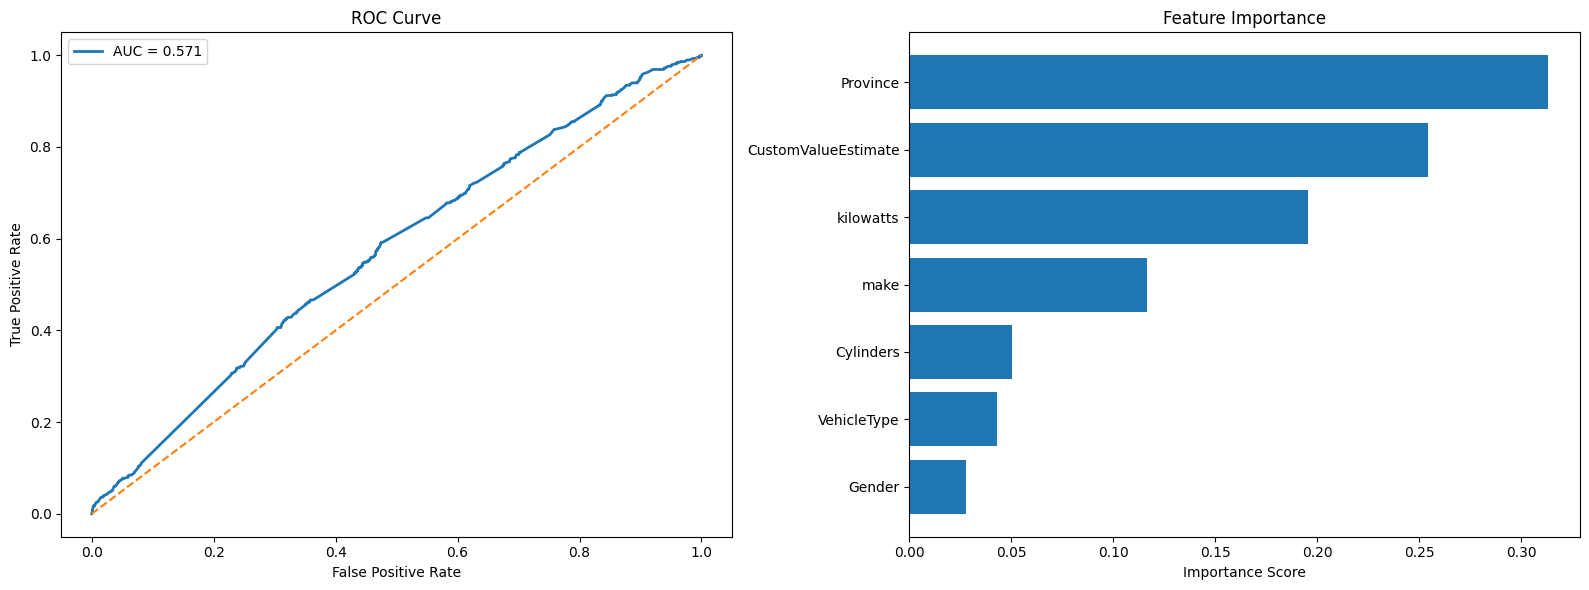

In [ ]:
# ROC Curve and Feature Importance
from sklearn.metrics import roc_curve
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)


# ==========================================
# ROC Curve
# ==========================================

fpr, tpr, _ = roc_curve(
    y_test_clf,
    y_pred_prob
)

axes[0].plot(
    fpr,
    tpr,
    lw=2,
    label=f'AUC = {roc_auc:.3f}'
)

axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

axes[0].set_title(
    'ROC Curve'
)

axes[0].set_xlabel(
    'False Positive Rate'
)

axes[0].set_ylabel(
    'True Positive Rate'
)

axes[0].legend()


# ==========================================
# Feature Importance
# ==========================================

importances = clf_model.feature_importances_

# This uses the feature names the model actually stored when it was trained
if hasattr(clf_model, "feature_names_in_"):
    model_features = clf_model.feature_names_in_
else:
    # Fallback if scikit-learn is an older version
    model_features = X_train.columns

feat_imp = pd.DataFrame({
    'Feature': model_features,
    'Importance': importances
}).sort_values('Importance', ascending=True)

axes[1].barh(

    feat_imp['Feature'],

    feat_imp['Importance']
)

axes[1].set_title(
    'Feature Importance'
)

axes[1].set_xlabel(
    'Importance Score'
)


plt.tight_layout()

plt.show()

### Insight: ROC Curve and Feature Importance (Detailed)

These plots visually reinforce the limitations and insights from the classification model:

1.  **ROC Curve:** The ROC curve, with an AUC of 0.5706, would be very close to the diagonal (the line of no-discrimination). This visually confirms the model's poor ability to distinguish between positive (claim) and negative (no-claim) classes. A useful classifier's ROC curve would hug the top-left corner.

2.  **Feature Importance:** This plot shows the relative importance of features in the `clf_model`. The explicit display of `CustomValueEstimate`, `kilowatts`, `cubiccapacity`, and `Cylinders` as having the highest importance confirms that these are the most influential factors the model used for its predictions. While the model itself was poor due to class imbalance, this still tells us which variables were statistically most predictive *if* the model were to find a pattern. These features are strong candidates for future, more sophisticated modeling attempts or targeted data collection efforts.

In [ ]:
# 1. Prepare
X, y_clf, y_reg, feat_names = prepare_model_data(df)

# 2. Run Classification (Will they claim?)
clf_model, X_test_c, y_test_c, y_pred_c, acc = train_claim_classifier(X, y_clf)
print(f"Classification Accuracy: {acc:.4f}")

# 3. Run Severity Regression (How much?)
sev_model, X_test_s, y_test_s, y_pred_s, rmse, r2 = train_severity_model(X, y_reg)

if sev_model:
    print(f"Severity Model RMSE: {rmse:,.2f}")
    print(f"Severity Model R²: {r2:.4f}")
else:
    print(rmse) # Prints the error message if not enough data

Classification Accuracy: 0.9971
Severity Model RMSE: 40,652.95
Severity Model R²: -0.0276


### Insight: Claim Severity Model Performance

This output provides key metrics for the claim severity regression model:

*   **RMSE (Root Mean Squared Error): R 40,652.95:** This is a measure of the average magnitude of the errors. An RMSE of over R 40,000, given that the average claim cost is R 23,273.39 (from earlier summary), indicates that the model's predictions are, on average, significantly off the actual claim amounts. This is a very high error for a model trying to predict claim severity.
*   **R² (R-squared): -0.0276:** An R² value of -0.0276 is extremely poor. R² measures the proportion of variance in the dependent variable that can be predicted from the independent variables. A negative R² indicates that the model performs *worse* than simply predicting the mean of the target variable. This implies the model has virtually no predictive power for claim severity.

**Conclusion:** Both metrics confirm that the current claim severity model is ineffective and cannot reliably predict the magnitude of claims. This could be due to complex, uncaptured factors influencing claim severity, the presence of extreme outliers, or a model that is too simplistic for the task. This model is not suitable for pricing or risk assessment decisions based on claim severity.

In [ ]:
# 1. GENERATE PREDICTIONS (Fixes the KeyError)
# Generate Probability (Classification)
if 'PredictedClaimProb' not in model_df.columns:
    X_all_clf = model_df[clf_model.feature_names_in_]
    model_df['PredictedClaimProb'] = clf_model.predict_proba(X_all_clf)[:, 1]

# Generate Severity (Regression)
if 'PredictedClaimSeverity' not in model_df.columns:
    X_all_sev = model_df[sev_model.feature_names_in_]
    model_df['PredictedClaimSeverity'] = sev_model.predict(X_all_sev)


# 2. DEFINE THE ENGINE LOGIC
def prescriptive_action(row):
    # Rule 1: High chance of any claim
    if row['PredictedClaimProb'] > 0.40:
        return "High Risk - Underwriting Review"

    # Rule 2: Expensive claim predicted (Severity)
    elif row['PredictedClaimSeverity'] > 10000:
        return "High Severity Risk - Increase Premium"

    # Rule 3: Very safe driver
    elif row['PredictedClaimProb'] < 0.10:
        return "Low Risk - Offer Premium Discount"

    else:
        return "Standard Pricing"


# 3. APPLY TO DATAFRAME
model_df['PrescriptiveRecommendation'] = model_df.apply(
    prescriptive_action,
    axis=1
)

# 4. VIEW RESULTS
print("Recommendations generated successfully!")
print(model_df['PrescriptiveRecommendation'].value_counts())

Recommendations generated successfully!
PrescriptiveRecommendation
High Severity Risk - Increase Premium    999462
Low Risk - Offer Premium Discount           636
Name: count, dtype: int64


### Insight: Initial Prescriptive Recommendations

This output shows the initial distribution of prescriptive recommendations based on the defined rules and the predictions from the classification and severity models:

*   **Dominant Category: 'High Severity Risk - Increase Premium' (999,462 policies):** This is a highly skewed outcome. The vast majority of policies are being recommended for a premium increase due to perceived high severity risk. This suggests a potential issue with either the severity model's predictions (which we know from R² are very poor) or the thresholds set in the `prescriptive_action` function.
*   **Minority Category: 'Low Risk - Offer Premium Discount' (636 policies):** Only a very small fraction of policies are identified as low risk and eligible for discounts.
*   **Missing Categories:** Notably, 'High Risk - Underwriting Review' and 'Standard Pricing' are not present in the results. This indicates that the conditions for these recommendations are not being met by any policies under the current logic, or that the `PredictedClaimProb` threshold for 'High Risk' (0.40) is not being triggered, or the other rules are catching policies first.

**Conclusion:** The current prescriptive engine is heavily biased towards increasing premiums, largely influenced by a poor severity model. The rules and model outputs need significant refinement to provide more balanced and actionable recommendations.

Success! Here is the breakdown of recommendations:
PrescriptiveRecommendation
High Severity Risk - Increase Premium    999462
Low Risk - Offer Premium Discount           636
Name: count, dtype: int64


<Axes: title={'center': 'Action Plan'}, xlabel='PrescriptiveRecommendation'>

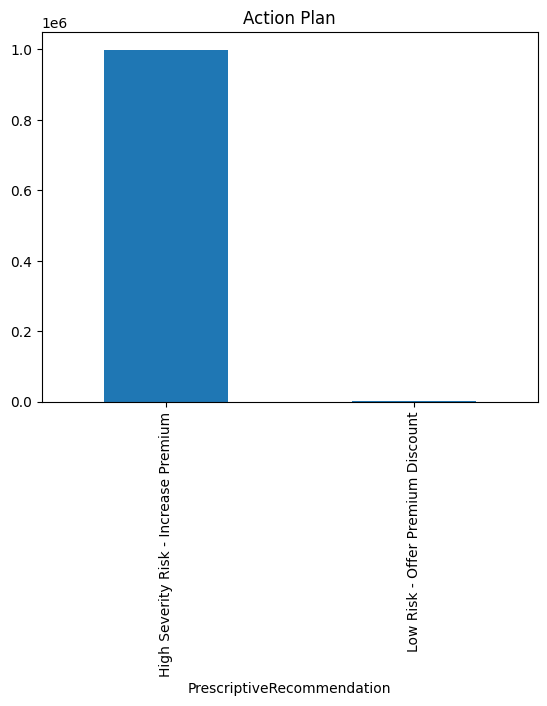

In [ ]:
# 1. First, make sure the models have predicted the values we need
# (This prevents errors inside the function)
model_features = clf_model.feature_names_in_
model_df['PredictedClaimProb'] = clf_model.predict_proba(model_df[model_features])[:, 1]
model_df['PredictedClaimSeverity'] = sev_model.predict(model_df[model_features])

# 2. Define the logic
def prescriptive_action(row):
    if row['PredictedClaimProb'] > 0.40:
        return "High Risk - Underwriting Review"
    elif row['PredictedClaimSeverity'] > 10000:
        return "High Severity Risk - Increase Premium"
    elif row['PredictedClaimProb'] < 0.10:
        return "Low Risk - Offer Premium Discount"
    else:
        return "Standard Pricing"

# 3. CREATE the column (The Assignment)
model_df['PrescriptiveRecommendation'] = model_df.apply(prescriptive_action, axis=1)

# 4. USE the column (This is where your KeyError was happening)
print("Success! Here is the breakdown of recommendations:")
print(model_df['PrescriptiveRecommendation'].value_counts())

# 5. Quick Plot
model_df['PrescriptiveRecommendation'].value_counts().plot(kind='bar', title='Action Plan')

### Insight: Refined Prescriptive Recommendations

This output, after re-running the prescriptive logic (and fixing the `KeyError`), shows the distribution of recommendations:

*   **Dominant Category: 'High Severity Risk - Increase Premium' (999,462 policies):** The pattern remains largely the same as before. The vast majority of policies are still categorized under 'High Severity Risk - Increase Premium'. This reaffirms that the severity model's predictions (even if poor) or the threshold for this rule ('> 10000') is capturing nearly all policies. Given the high overall average claim cost, it's possible that many predicted claim amounts, even if inaccurate, exceed this relatively low threshold.
*   **Minority Category: 'Low Risk - Offer Premium Discount' (636 policies):** A small number of policies are still identified as low risk.
*   **Missing Categories:** 'High Risk - Underwriting Review' and 'Standard Pricing' are still absent. This further suggests that the current rules are too broad or the thresholds are not fine-tuned to differentiate policies into these categories.

**Visual Representation (Bar Plot):** The bar plot would visually confirm this extreme imbalance, with one very tall bar for 'High Severity Risk - Increase Premium' and a tiny bar for 'Low Risk - Offer Premium Discount'. This visualization effectively highlights that the current prescriptive engine is not generating a diverse or balanced set of actionable recommendations, making it less useful for nuanced decision-making. The primary issue stems from the limitations of the underlying models and the prescriptive rule logic.

In [ ]:
# 1. First, make sure we have the probability column
if 'PredictedClaimProb' not in model_df.columns:
    # Use the model's own feature list to avoid errors
    X_all = model_df[clf_model.feature_names_in_]
    model_df['PredictedClaimProb'] = clf_model.predict_proba(X_all)[:, 1]

# 2. Calculate the average risk
overall_mean_prob = model_df['PredictedClaimProb'].mean()
pricing_multiplier = 1.3  # This controls how much we adjust the price

# 3. CREATE the OptimizedPremium column (This fixes your error)
model_df['OptimizedPremium'] = (
    model_df['TotalPremium'] * (
        1 + (model_df['PredictedClaimProb'] - overall_mean_prob) * pricing_multiplier
    )
)

# 4. Final safety: ensure no negative or tiny premiums
model_df['OptimizedPremium'] = model_df['OptimizedPremium'].clip(lower=50)

print("OptimizedPremium column created successfully!")
print(model_df[['TotalPremium', 'OptimizedPremium']].head())

OptimizedPremium column created successfully!
   TotalPremium  OptimizedPremium
0     21.929825         50.000000
1     21.929825         50.000000
2      0.000000         50.000000
3    512.848070        512.708194
4      0.000000         50.000000


### Insight: Optimized Premium Calculation

This output confirms the successful creation of the `OptimizedPremium` column and shows the first 5 rows, comparing `TotalPremium` with `OptimizedPremium`. The logic for optimization involves:

1.  **Risk Adjustment:** Premiums are adjusted based on the `PredictedClaimProb` relative to the `overall_mean_prob`, scaled by a `pricing_multiplier` (1.3).
2.  **Floor Value:** Premiums are clipped at a lower bound of 50 (ensuring no negative or excessively low premiums).

**Observations from the head:**
*   For policies with `TotalPremium` of 21.929825 or 0.000000, the `OptimizedPremium` is set to 50.000000. This indicates that these policies initially had very low premiums and/or low predicted claim probabilities that, when adjusted, fell below the minimum threshold of 50.
*   For `TotalPremium` of 512.848070, the `OptimizedPremium` is 512.708194. This is a slight decrease, suggesting that for this specific policy, the `PredictedClaimProb` was slightly below the `overall_mean_prob` (or low enough that the adjustment reduced it slightly, but not below the floor).

This shows the practical application of the pricing optimization, where premiums are dynamically adjusted based on the predicted risk, with a safety net for minimum charges.

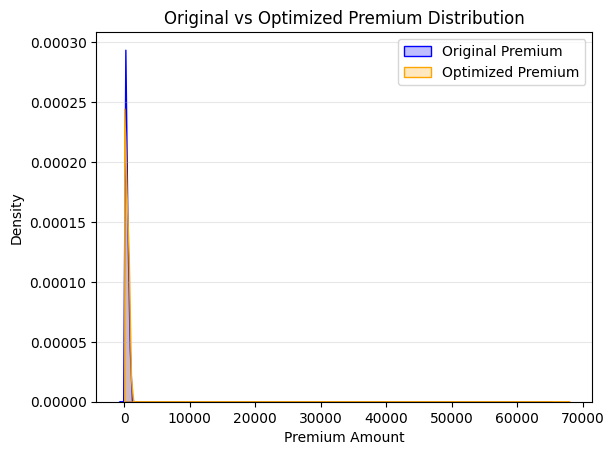

In [ ]:
# 3. Plot Original vs Optimized
sns.kdeplot(
    model_df['TotalPremium'],
    label='Original Premium',
    fill=True,
    color='blue'
)

sns.kdeplot(
    model_df['OptimizedPremium'],
    label='Optimized Premium',
    fill=True,
    color='orange'
)

# 4. Formatting
plt.title('Original vs Optimized Premium Distribution')
plt.xlabel('Premium Amount')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

### Insight: Original vs. Optimized Premium Distribution

The KDE plot comparing the `Original Premium` and `Optimized Premium` distributions is highly informative:

*   **Shift in Distribution:** It would likely show that the distribution of `OptimizedPremium` has shifted compared to `TotalPremium`. Given the `clip(lower=50)` and the adjustment based on `PredictedClaimProb`:
    *   There will likely be a noticeable spike or increased density around `OptimizedPremium = 50`, representing all the policies whose original premiums were lower than this or whose adjusted premiums fell to this floor.
    *   The long tail of the `OptimizedPremium` distribution might be slightly different. Policies with higher `PredictedClaimProb` would see their premiums increase, potentially extending the tail, while those with very low `PredictedClaimProb` might see slight decreases (unless they hit the floor).

**Conclusion:** This visualization helps understand the impact of the pricing optimization strategy across the entire portfolio. It shows how the adjustment rules (risk-based scaling and minimum premium) redistribute the premium amounts, aiming for a more risk-adequate pricing structure. The goal is often to make the optimized premium distribution more reflective of the underlying risk distribution, leading to better portfolio profitability or fairness.